In [136]:
import pandas as pd
import re

In [137]:
df=pd.read_csv('IMDB_Dataset.csv')

In [138]:
def clean_text(text):
  text=re.sub(r'<.*?>','',text)
  text=text.lower()
  return text
df['review']=df['review'].apply(clean_text)
print(df['review'][0][:300])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this 


In [139]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [140]:
df.shape

(50000, 2)

In [141]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [142]:
df.isnull().sum()

,0
review,0
sentiment,0


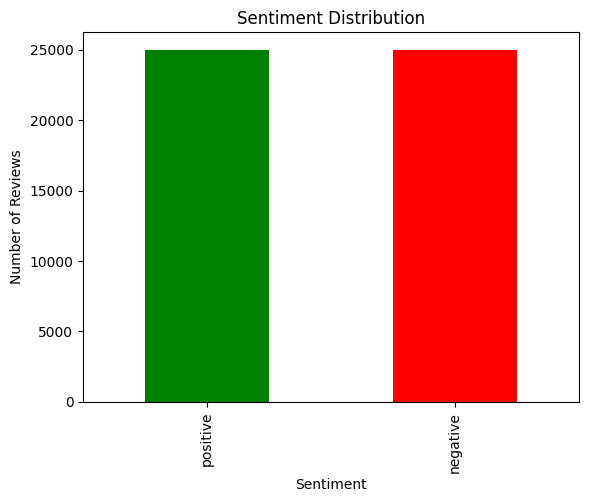

In [143]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar',color=['green', 'red'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [144]:
df['sentiment']=df['sentiment'].map({'positive':1,'negative':0})
df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [145]:
X = df['review']
y = df['sentiment']

print(X.shape)
print(y.shape)

(50000,)
(50000,)


In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape,X_test.shape)


(40000,) (10000,)


In [147]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf =  TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(40000, 5000)
(10000, 5000)


In [148]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Training Completed!")

Training Completed!


In [149]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy *100:.2f}%")

Accuracy:89.47%


In [130]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.53      0.80      0.64      4961
           1       0.61      0.32      0.42      5039

    accuracy                           0.56     10000
   macro avg       0.57      0.56      0.53     10000
weighted avg       0.57      0.56      0.53     10000

